In [10]:
from classy import Class

import os
import copy
import yaml
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

from matplotlib import rc
from scipy.interpolate import interp1d

rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)
#matplotlib.rc('font', **font)
matplotlib.rcParams['legend.fontsize']='medium'
plt.rcParams["figure.figsize"] = [8.0,6.0]

# warmup

run a fiducial cosmology

In [11]:
params_EDE = {

    "output": "tCl,lCl,mPk",
    # LCDM parameters
    "omega_b": 0.02251,
    "omega_cdm": 0.1320,
    "H0": 72.81,
    "tau_reio": 0.068,
    "A_s": 2.191e-9,
    "n_s": 0.9860,

    # neutrinos
    "N_ur": 2.0328,
    "N_ncdm": 1,
    "deg_ncdm": 1,
    "m_ncdm": 0.06,
    "T_ncdm": 0.71611,

    # EDE parameters
    "scf_potential": "axion",
    "n_axion": 2.6,
    "f_axion": 0.1,
    "m_axion": 1e4,
    "scf_parameters": '2.72,0',

    # extra EDE parameters
    "scf_evolve_as_fluid": "no",
    "scf_evolve_like_axionCAMB": "no",
    "do_shooting": "no",
    "do_shooting_scf": "no",
    "attractor_ic_scf": "no",

    # verbosity
    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    "perturbations_verbose": 1,
    "transfer_verbose": 1,
    "primordial_verbose": 1,
    #"spectra_verbose": 1,
    # "nonlinear_verbose": 1,
    "lensing_verbose": 1,
    "output_verbose": 1,
    "l_max_scalars":5000,
}


In [12]:
params_mEDE = {
    # "compute_sigma8": "yes",

    "output": "tCl,lCl,mPk",
    "omega_b": 0.02251,
    "omega_cdm": 0.1320,
    "H0": 72.81,
    "tau_reio": 0.068,
    "A_s": 2.191e-9,
    "n_s": 0.9860,

    "N_ur": 2.0328,
    "N_ncdm": 1,
    "deg_ncdm": 1,
    "m_ncdm": 0.06,
    "T_ncdm": 0.7161,

    "N_mscf": 8,
    "n_axion_mscf": '2.6,2.6,2.6,2.6,2.6,2.6,2.6,2.6',
    # "f_axion_mscf": '0.1, 0.1, 0.1, 0.1, 0.1, 0.1',
    # "m_mscf": '1e3, 5e3, 1e4, 5e4, 1e5, 5e5',
    "log10_maxion_ac": '-1.6,-2,-2.4,-2.8,-3.2,-3.6,-4.,-4.4',
    "fraction_maxion_ac": '0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1',
    "theta_ini_mscf": '2.6,2.6,2.6,2.6,2.6,2.6,2.6,2.6',
    "theta_prime_ini_mscf": '0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0',
    "do_shooting_mscf": 'y',
    "do_shooting": 'y',
    "background_Nloga": 100000,
    "tol_shooting_deltaF":0.1,
    "tol_shooting_deltax":0.1,
    # "alpha_squared_mscf": -30.,
    # "power_of_mu_mscf": -30.,

    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    "perturbations_verbose": 1,
    "transfer_verbose": 1,
    "primordial_verbose": 1,
    # "spectra_verbose": 1,
    # "nonlinear_verbose": 1,
    "lensing_verbose": 1,
    "output_verbose": 1,
    "l_max_scalars":3000,
}


In [13]:
EDE1 = Class()
EDEm = Class()
EDE1.set(params_EDE)
EDEm.set(params_mEDE)

1344 reached background.c, freeing memory


True

In [14]:
bg1 = EDE1.get_background()
print(bg1.keys())
bg_m = EDEm.get_background()
print(bg_m.keys())
derived = EDE1.get_current_derived_parameters(['z_eq','z_rec'])

Reading input parameters
Reading input parameters
 -> matched budget equations by adjusting Omega_Lambda = 0.70726
Running CLASS version v3.3.0
Computing background
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.313858e+01 eV)
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.313858e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 adjusted Omega_Lambda to incorporate the axion contribution; new Omega_Lambda = 7.072569e-01  
 adjusted Omega_Lambda to incorporate the axion contribution; new Omega_Lambda = 7.072569e-01  
 -> age = 13.032250 Gyr
 -> conformal age = 13493.666196 Mpc
 -> H0 = 72.810000 km/s/Mpc
 -> N_eff = 3.046 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3696.298043
    corresponding to conformal time = 103

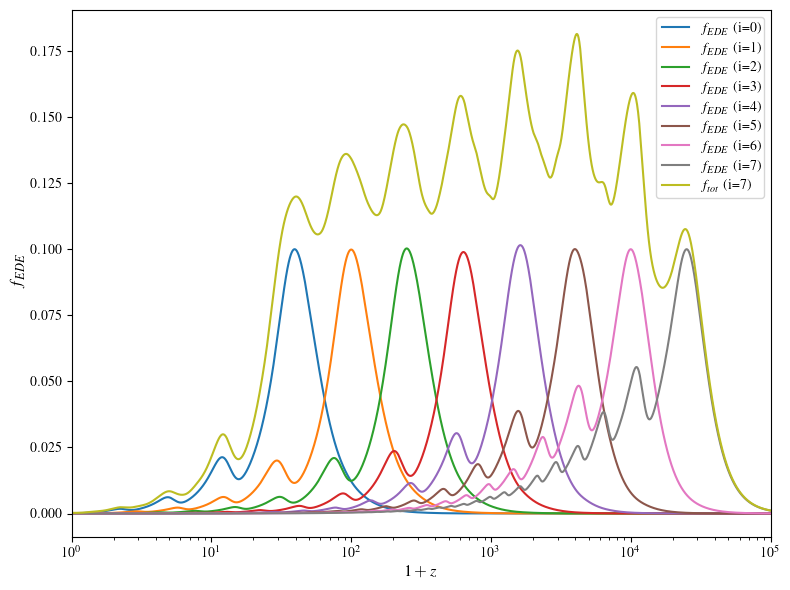

In [26]:
# Prepare the data
z = bg_m['z']
f_EDE_tot = np.zeros(100000,)

fig, ax = plt.subplots()
for i in range(params_mEDE['N_mscf']):  # Corrected to use params_mEDE
    rho_EDE_m = bg_m[f'(.)rho_mscf[{i}]']
    f_EDE_m = rho_EDE_m / bg_m['(.)rho_tot']
    ax.plot(1+z, f_EDE_m, label=f'$f_{{EDE}}$ (i={i})')
    f_EDE_tot += f_EDE_m
    
ax.plot(1+z, f_EDE_tot, label=f'$f_{{tot}}$')
ax.set_xlabel(r'$1+z$',fontsize='large')
ax.set_ylabel(r'$f_{EDE}$',fontsize='large')
#ax.set_ylim(0, .1)  # Set based on physical expectations
#ax.tick_params(colors='darkred')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels)
ax.set_xscale('log')
ax.set_yscale('linear')
ax.set_xlim(1,1e5)
#ax.set_ylim(1e-7,5e-1)

plt.title("mAxiCLASS: Fraction of EDE in each field (theory parameters)")
plt.tight_layout()
plt.show()

# Compute $C_l$ 

1344 reached background.c, freeing memory
Reading input parameters
N_mscf != 0
Reading input parameters
Computing unknown input parameters 2 
entering input_get_guess... 
 -> matched budget equations by adjusting Omega_Lambda = 0.70726
index_guess_long at start of switch = 0
index_guess_long at start of switch = 8
1344 reached background.c, freeing memory
pre bad line 
entering input_try_unknown_parameters... 
input_try_unknown_parameters: unknown_parameters_size = 16, unknown_names_size = 2, N_mscf = 8
here reached glorb?here reached glurb? -> matched budget equations by adjusting Omega_Lambda = 0.70726
here reached glarb?entering mscf territory in background_init
1344 reached background.c, freeing memory
entering input_try_unknown_parameters... 
input_try_unknown_parameters: unknown_parameters_size = 16, unknown_names_size = 2, N_mscf = 8
here reached glorb?here reached glurb? -> matched budget equations by adjusting Omega_Lambda = 0.70726
here reached glarb?entering mscf territory i

sion v3.3.0
Computing background
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.314248e+01 eV)
entering mscf territory in background_init
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.314248e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.01314
 -> age = 13.005497 Gyr
 -> conformal age = 13283.312596 Mpc
 -> H0 = 72.810000 km/s/Mpc
 -> N_eff = 3.04594 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 2752.667277
    corresponding to conformal time = 124.485989 Mpc
Computing thermodynamics using HyRec 2020
 -> with primordial helium mass fraction Y_He = 0.2454
 -> recombination (maximum of visibility function) at z = 1091.188741
    corresponding to conformal time = 254.901412 Mpc
    with comoving sound horizon = 131.377839 M

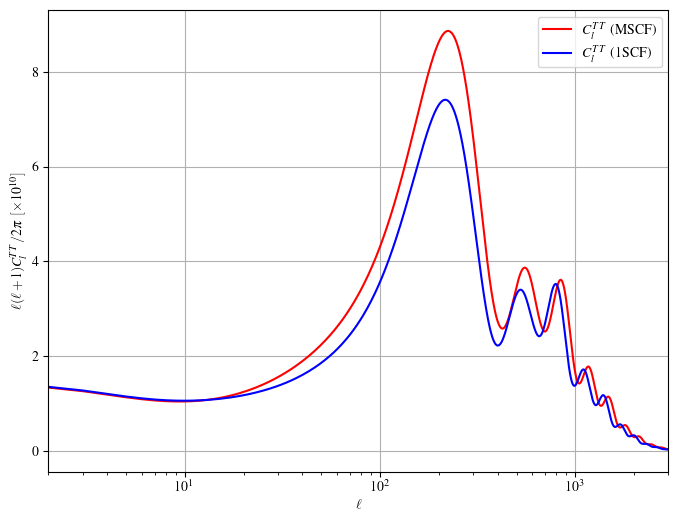

In [16]:
fig, ax = plt.subplots()
plt.xlim([2,3000])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell (\ell+1) C_l^{TT} / 2 \pi \,\,\, [\times 10^{10}]$")
plt.grid()
pi = np.pi#

cl_tot = EDEm.raw_cl(3000)
cl_tot_1 = EDE1.raw_cl(3000)
# cl_lensed = EDEm.lensed_cl(3000)
ell = cl_tot['ell']
ell_1 = cl_tot_1['ell']
factor = 1.e10*ell*(ell+1.)/2./pi
plt.semilogx(ell,factor*cl_tot['tt'],'r-',label=r'$C_l^{TT}$ (MSCF)')
plt.semilogx(ell,factor*cl_tot_1['tt'],'b-',label=r'$C_l^{TT}$ (1SCF)')

plt.legend()
    

# Matter power spectrum

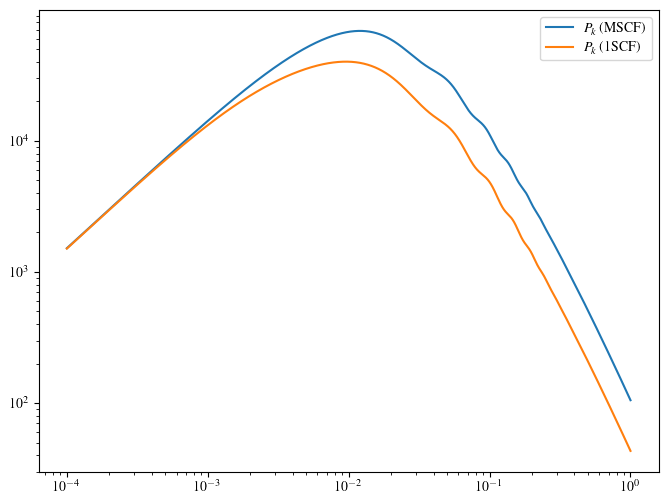

In [17]:
kk = np.logspace(-4, 0, 10000)
Pk_axion1 = [EDE1.pk(ki, 0) for ki in kk]

Pk_axion_m = [EDEm.pk(ki, 0) for ki in kk]

fig, ax = plt.subplots()
plt.plot(kk,Pk_axion1,label=r'$P_k$ (MSCF)')
plt.plot(kk,Pk_axion_m,label=r'$P_k$ (1SCF)')
ax.set_xscale('log')
ax.set_yscale('log')
plt.legend()

In [18]:
EDE1.empty()
EDEm.empty()